In [1]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# División entrenamiento/prueba
from sklearn.model_selection import train_test_split

# Escalado de datos
from sklearn.preprocessing import StandardScaler

# Modelo de regresión lineal
from sklearn.linear_model import LinearRegression

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# ==========================================
# CARGAR DATASET LIMPIO
# ==========================================

# Ruta dataset limpio
ruta = "../data/processed/energy_dataset_clean.csv"

# Cargar dataset
df = pd.read_csv(
    
    ruta,
    
    # Convertir datetime automáticamente
    parse_dates=["Datetime"]
)

# Mostrar primeras filas
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,Weekday
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16,17,Saturday
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16,17,Saturday
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16,17,Saturday
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16,17,Saturday
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16,17,Saturday


In [3]:
# ==========================================
# SELECCIÓN DE VARIABLES
# ==========================================

# Variables de entrada
X = df[
    [
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
]

# Variable objetivo
y = df["Global_active_power"]

# Mostrar dimensiones
print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

Dimensiones de X:
(1591650, 6)

Dimensiones de y:
(1591650,)


In [4]:
# ==========================================
# DIVISIÓN TRAIN Y TEST
# ==========================================

# Librería para dividir datos
from sklearn.model_selection import train_test_split

# Dividir dataset
X_train, X_test, y_train, y_test = train_test_split(
    
    # Variables de entrada
    X,
    
    # Variable objetivo
    y,
    
    # 20% para pruebas
    test_size=0.2,
    
    # Semilla aleatoria
    random_state=42
)

# Mostrar dimensiones
print("X_train:")
print(X_train.shape)

print("\nX_test:")
print(X_test.shape)

print("\ny_train:")
print(y_train.shape)

print("\ny_test:")
print(y_test.shape)

X_train:
(1273320, 6)

X_test:
(318330, 6)

y_train:
(1273320,)

y_test:
(318330,)


In [5]:
# ==========================================
# ESCALADO DE DATOS
# ==========================================

# Librería para escalar datos
from sklearn.preprocessing import StandardScaler

# Crear escalador
scaler = StandardScaler()

# Escalar entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Escalar prueba
X_test_scaled = scaler.transform(X_test)

# Mostrar dimensiones
print("X_train_scaled:")
print(X_train_scaled.shape)

print("\nX_test_scaled:")
print(X_test_scaled.shape)

X_train_scaled:
(1273320, 6)

X_test_scaled:
(318330, 6)


In [6]:
# ==========================================
# ENTRENAMIENTO LINEAR REGRESSION
# ==========================================

# Crear modelo
lr_model = LinearRegression()

# Entrenar modelo
lr_model.fit(
    
    X_train_scaled,
    
    y_train
)

# Mensaje
print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [7]:
# ==========================================
# PREDICCIONES
# ==========================================

# Realizar predicciones
lr_pred = lr_model.predict(
    X_test_scaled
)

# Mostrar primeras predicciones
print(lr_pred[:10])

[1.66126469 1.74017326 0.56747688 4.16468401 0.0874243  1.17247434
 0.15321639 0.3681078  1.51700328 5.12456694]


In [8]:
# ==========================================
# MÉTRICAS DEL MODELO
# ==========================================

# Calcular MAE
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

# Calcular MSE
lr_mse = mean_squared_error(
    y_test,
    lr_pred
)

# Calcular RMSE
lr_rmse = np.sqrt(lr_mse)

# Calcular R2
lr_r2 = r2_score(
    y_test,
    lr_pred
)

# Mostrar métricas
print("MAE:", lr_mae)

print("\nMSE:", lr_mse)

print("\nRMSE:", lr_rmse)

print("\nR2:", lr_r2)

MAE: 0.02631166959560256

MSE: 0.0016710991651301729

RMSE: 0.04087907979798681

R2: 0.998603335928999


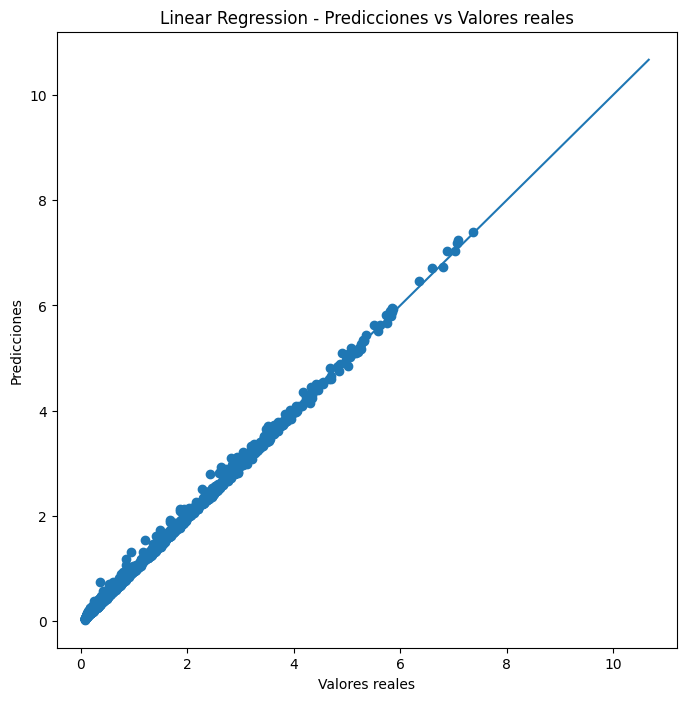

In [9]:
# ==========================================
# SCATTER PLOT
# ==========================================

# Crear figura
plt.figure(figsize=(8,8))

# Scatter plot
plt.scatter(
    
    # Valores reales
    y_test[:3000],
    
    # Predicciones
    lr_pred[:3000]
)

# Línea ideal
plt.plot(
    
    [y_test.min(), y_test.max()],
    
    [y_test.min(), y_test.max()]
)

# Título
plt.title(
    "Linear Regression - Predicciones vs Valores reales"
)

# Eje X
plt.xlabel("Valores reales")

# Eje Y
plt.ylabel("Predicciones")

# Mostrar gráfica
plt.show()

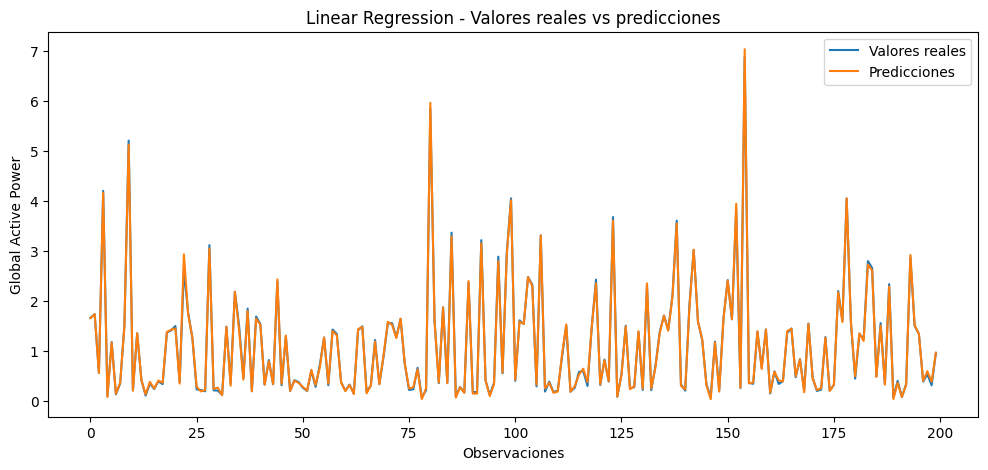

In [10]:
# ==========================================
# REAL VS PREDICCIÓN
# ==========================================

# Crear figura
plt.figure(figsize=(12,5))

# Valores reales
plt.plot(
    
    # Primeras observaciones
    y_test.values[:200],
    
    # Etiqueta
    label="Valores reales"
)

# Predicciones
plt.plot(
    
    # Predicciones modelo
    lr_pred[:200],
    
    # Etiqueta
    label="Predicciones"
)

# Título
plt.title(
    "Linear Regression - Valores reales vs predicciones"
)

# Eje X
plt.xlabel("Observaciones")

# Eje Y
plt.ylabel("Global Active Power")

# Mostrar leyenda
plt.legend()

# Mostrar gráfica
plt.show()

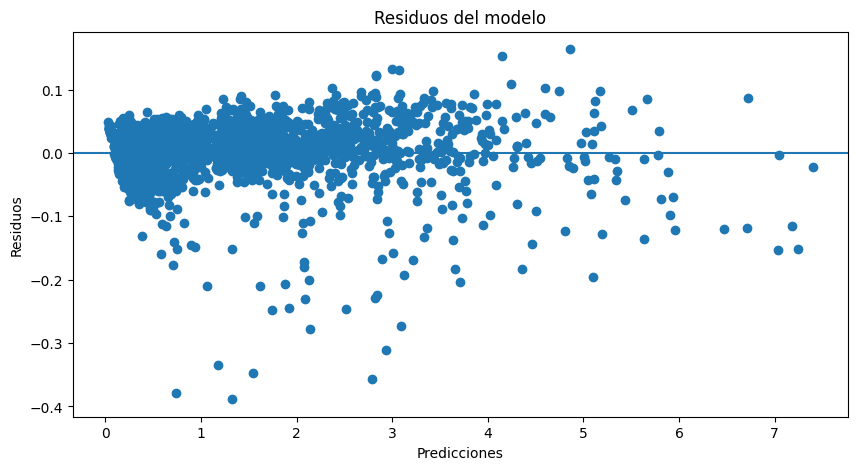

In [11]:
# ==========================================
# GRÁFICA DE RESIDUOS
# ==========================================

# Calcular residuos
residuos = y_test - lr_pred

# Crear figura
plt.figure(figsize=(10,5))

# Scatter residuos
plt.scatter(
    
    # Predicciones
    lr_pred[:3000],
    
    # Residuos
    residuos[:3000]
)

# Línea horizontal ideal
plt.axhline(
    
    y=0
)

# Título
plt.title(
    "Residuos del modelo"
)

# Eje X
plt.xlabel("Predicciones")

# Eje Y
plt.ylabel("Residuos")

# Mostrar gráfica
plt.show()

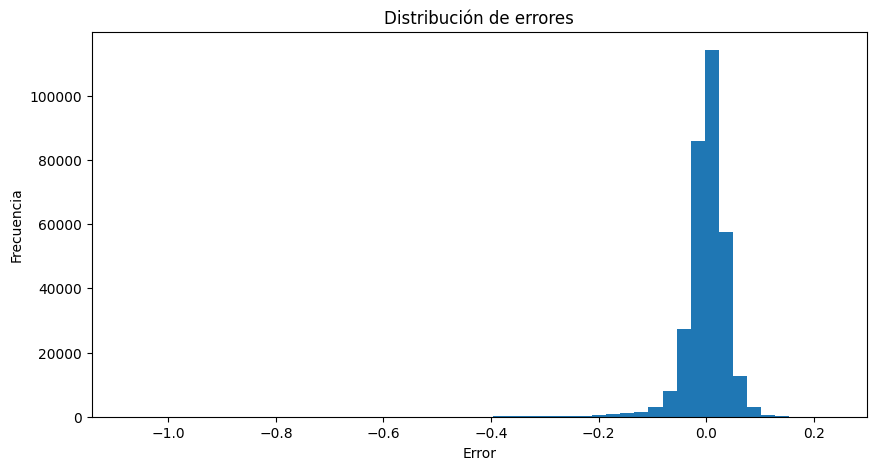

In [12]:
# ==========================================
# HISTOGRAMA DE ERRORES
# ==========================================

# Crear figura
plt.figure(figsize=(10,5))

# Histograma residuos
plt.hist(
    
    residuos,
    
    # Número de divisiones
    bins=50
)

# Título
plt.title(
    "Distribución de errores"
)

# Eje X
plt.xlabel("Error")

# Eje Y
plt.ylabel("Frecuencia")

# Mostrar gráfica
plt.show()

In [13]:
# ==========================================
# GUARDAR MÉTRICAS
# ==========================================

# Crear dataframe métricas
lr_metrics = pd.DataFrame({

    "Modelo": ["Linear Regression"],

    "MAE": [lr_mae],

    "RMSE": [lr_rmse],

    "R2": [lr_r2]
})

# Guardar CSV
lr_metrics.to_csv(
    
    "../results/linear_regression_metrics.csv",
    
    index=False
)

print("Métricas guardadas")

Métricas guardadas
